In [1]:
import napari
import numpy as np
from aicsimageio import AICSImage

import pandas as pd
from skimage import measure


import tifffile as tf
import matplotlib.pyplot as plt
import xarray as xr
from tifffile import tifffile
import tifftools
import os
from matplotlib import pyplot as plt
from os.path import sep
from skimage import io
from PIL import Image
import imageio


from skimage.measure import regionprops_table

import seaborn as sns

import czifile

import math

from pathlib import Path
import re


In [2]:
# on sansa MACbook





data_dir = Path('/Users/sansachen/Downloads/lab/confocal/7_zipursky/mean signal value csv')

# 2. Grab every fly*_mean_signals.csv in there
csv_files = list(data_dir.glob('fly*_mean_signals.csv'))

# 3. Read them into a dict of DataFrames,
#    keyed by 'fly#'
data = {
    f.stem.replace('_mean_signals', ''): pd.read_csv(f)
    for f in csv_files
}

# 4. (Optional) Quick sanity‑check
for name, df in data.items():
    print(name, df.shape)

# 5. Assign each DataFrame to a variable named after its key
for fly_name, df in data.items():
    globals()[fly_name] = df

fly11 (18, 5)
fly7 (18, 5)
fly3 (18, 5)
fly8 (18, 5)
fly6 (18, 5)
fly10 (18, 5)
fly9 (18, 5)
fly5 (18, 5)
fly13 (18, 5)
fly1 (18, 5)
fly12 (18, 5)
fly4 (18, 5)


In [25]:
fly7

,glomerulus,mean_red,mean_green,total_red,total_green
0,L9,119.530189,17.684653,54761364.0,6948485.0
1,L8,98.799708,12.713668,4319196.0,403259.0
2,L7,76.669910,17.160239,1908521.0,376774.0
3,L6,79.564674,17.919903,6298327.0,1023208.0
4,L5,82.436950,16.730335,5326438.0,806332.0
5,L4,87.751278,19.350997,5388353.0,957598.0
6,L3,95.457742,14.954691,6956252.0,762866.0
7,L2,104.256448,11.301636,4166999.0,350398.0
8,L1,138.238451,15.356616,49728767.0,4795966.0
9,R1,109.243786,11.331375,8056765.0,512950.0


In [5]:
fly_subtype = pd.DataFrame({
    'fly': [
        'fly1','fly3','fly4','fly5','fly6',
        'fly7','fly8','fly9','fly10','fly11',
        'fly12','fly13'
    ],
    'subtype': [
        'L3R6','L7R2','L3R6','L1L9R8','L7R2',
        'L1L9R8','L6R3','L3R6','L1L9R8','L2R7',
        'L8R1R9','L7R2'
    ]
})

In [6]:
tokens = fly_subtype['subtype'].str.findall(r'[LR]\d+')

# 2. Figure out the maximum number of tokens any row has
max_parts = tokens.map(len).max()

# 3. Create column names dynamically (part1, part2, …)
col_names = [f'part{i+1}' for i in range(max_parts)]

# 4. “Unpack” the lists of tokens into separate columns
fly_subtype[col_names] = pd.DataFrame(tokens.tolist(), index=fly_subtype.index)

fly_subtype

,fly,subtype,part1,part2,part3
0,fly1,L3R6,L3,R6,None
1,fly3,L7R2,L7,R2,None
2,fly4,L3R6,L3,R6,None
3,fly5,L1L9R8,L1,L9,R8
4,fly6,L7R2,L7,R2,None
5,fly7,L1L9R8,L1,L9,R8
6,fly8,L6R3,L6,R3,None
7,fly9,L3R6,L3,R6,None
8,fly10,L1L9R8,L1,L9,R8
9,fly11,L2R7,L2,R7,None


In [7]:
subtype_to_csv_subtype = pd.DataFrame({
    'subtype': [
        'L9','L8','L7','L6','L5','L4','L3','L2','L1',
        'R1','R2','R3','R4','R5','R6','R7','R8','R9'
    ],
    'csv_subtype': [
        'glom_1','glom_2','glom_3','glom_4','glom_5','glom_6','glom_7','glom_8','glom_9',
        'glom_10','glom_11','glom_12','glom_13','glom_14','glom_15','glom_16','glom_17','glom_18'
    ]
})

# 2. Set 'subtype' as the index
subtype_to_csv_subtype = subtype_to_csv_subtype.set_index('subtype')

In [8]:
csv_to_subtype = {
    v: k
    for k, v in subtype_to_csv_subtype['csv_subtype'].items()
}

# 2. Create a new dict to hold the “_new” DataFrames
new_data = {}

for fly_name, df in data.items():
    # a) Identify the first column (currently holding glom_* values)
    first_col = df.columns[0]
    
    # b) Remap glom_* → subtype (L#/R#)
    df[first_col] = df[first_col].map(csv_to_subtype)
    
    # c) Rename that column to something meaningful
    df = df.rename(columns={ first_col: 'subtype' })
    
    # d) Store it under a new key with “_new” appended
    new_data[f'{fly_name}_new'] = df

# 3. (Optional) Inject into the global namespace so you can refer to fly1_new, fly3_new, etc.
for new_name, df in new_data.items():
    globals()[new_name] = df

In [24]:
# don't put this line in the previous cell!
fly5_new

,subtype,mean_red,mean_green,total_red,total_green
0,L9,722.423116,89.423544,200510703.0,24819773.0
1,L8,543.262223,70.216035,41402014.0,5351164.0
2,L7,511.671263,69.493748,80444956.0,10925807.0
3,L6,527.683710,62.298235,101037183.0,11928430.0
4,L5,490.952742,65.348951,70487558.0,9382345.0
5,L4,493.481073,58.269314,38549261.0,4551824.0
6,L3,477.295721,44.714108,21852030.0,2047146.0
7,L2,560.519954,52.841183,47543863.0,4482042.0
8,L1,685.092040,71.333490,296820922.0,30905734.0
9,R1,382.113995,32.748575,9114183.0,781119.0


In [10]:
for fly_name, df in new_data.items():
    # Split the first 9 rows into “left” and the rest into “right”
    left_df  = df.iloc[:9].reset_index(drop=True)
    right_df = df.iloc[9:].reset_index(drop=True)
    
    # Assign to new variables in the global namespace
    globals()[f"{fly_name}_left"]  = left_df
    globals()[f"{fly_name}_right"] = right_df


In [11]:
fly13_new_right

,subtype,mean_red,mean_green,total_red,total_green
0,R1,475.453792,60.628079,80814724.0,11739260.0
1,R2,726.300695,70.154702,320131124.0,34021893.0
2,R3,512.082539,60.532340,88657633.0,11791128.0
3,R4,423.927832,48.406145,38584245.0,5270100.0
4,R5,425.249871,60.147867,65678780.0,11238003.0
5,R6,459.583969,68.160927,104501352.0,18694812.0
6,R7,515.786850,74.096065,143328562.0,25157255.0
7,R8,554.876061,88.111819,86791061.0,16638949.0
8,R9,547.776852,86.909575,63020589.0,12080245.0


In [12]:
# 1. Gather all fly*_new_left and fly*_new_right DataFrame names in globals
all_dfs = [name for name in globals() if re.match(r'fly\d+_new_(left|right)$', name)]

# 2. Exclude flies 5, 7, 10, and 12
exclude = {'fly5','fly7','fly10','fly12'}
subset_dfs = [name for name in all_dfs if name.split('_new_')[0] not in exclude]

# 3. Define ordering for left and right
left_order = [f'L{i}' for i in range(9, 0, -1)]
right_order = [f'R{i}' for i in range(1, 10)]

# 4. Loop over the subset and create shuffle_order DataFrames
for name in subset_dfs:
    df = globals()[name]
    fly = name.split('_new_')[0]       # e.g. 'fly3'
    side = name.split('_new_')[1]      # 'left' or 'right'
    codes = left_order if side == 'left' else right_order
    new_name = f"{name}_shuffle_order" # e.g. 'fly3_new_left_shuffle_order'
    
    # Build the new DataFrame
    shuffle_df = pd.DataFrame({'subtype': codes})
    
    # Determine which code to mark with 0
    part_col = 'part1' if side == 'left' else 'part2'
    target_code = fly_subtype.set_index('fly', drop=False).loc[fly, part_col]
    
    # Initialize second column and mark the target code
    shuffle_df['value'] = pd.NA
    shuffle_df.loc[shuffle_df['subtype'] == target_code, 'value'] = 0
    
    # Assign to globals
    globals()[new_name] = shuffle_df

In [13]:
fly1_new_left_shuffle_order

,subtype,value
0,L9,<NA>
1,L8,<NA>
2,L7,<NA>
3,L6,<NA>
4,L5,<NA>
5,L4,<NA>
6,L3,0
7,L2,<NA>
8,L1,<NA>


In [14]:
def fill_wrap_distances_left(df, first_col='subtype', second_col='value'):
    """
    Given a DataFrame where:
      - `first_col` is strings like 'L9' → numeric positions 9→1
      - `second_col` is NA except one row equals 0
    This will:
      1. find the row where second_col == 0,
      2. read its numeric position as the reference,
      3. compute wrap‑around distances in [-4..4],
      4. fill second_col accordingly.
    """
    # Extract numeric positions
    nums = df[first_col].str.extract(r'(\d+)').astype(int)[0]
    
    # Find reference numeric position
    ref_str = df.loc[df[second_col] == 0, first_col].iloc[0]
    ref = int(re.search(r'(\d+)', ref_str).group(1))
    
    n = len(df)  # here 9
    # Compute wrapped differences on the numeric series
    df[second_col] = ((nums - ref + n//2) % n) - n//2

    return df

def fill_wrap_distances_right(df, first_col='subtype', second_col='value'):
    """
    Given a DataFrame where:
      - `first_col` is strings like 'R1' → numeric positions 1→9
      - `second_col` is NA except one row equals 0
    This will:
      1. find the reference numeric position,
      2. compute the minimal signed distance on the circular scale,
      3. fill second_col with values in [-4..4].
    """
    # Extract numeric positions
    nums = df[first_col].str.extract(r'(\d+)').astype(int)[0]
    
    # Find reference numeric position
    ref_str = df.loc[df[second_col] == 0, first_col].iloc[0]
    ref = int(re.search(r'(\d+)', ref_str).group(1))
    
    n = len(df)  # here 9
    # Compute wrapped differences
    df[second_col] = ((nums - ref + n//2) % n) - n//2

    return df

In [15]:
def fill_wrap_distances_general(df, df_name, first_col='subtype', second_col='value'):
    if 'left' in df_name:
        return fill_wrap_distances_left(df.copy(), first_col=first_col, second_col=second_col)
    elif 'right' in df_name:
        return fill_wrap_distances_right(df.copy(), first_col=first_col, second_col=second_col)
    else:
        raise ValueError(f"DataFrame name '{df_name}' must contain 'left' or 'right'.")


In [16]:
shuffle_names = [
    name for name in globals()
    if re.match(r'fly\d+_new_(left|right)_shuffle_order$', name)
]

# Loop through them and apply the wrapper function in one go
for name in shuffle_names:
    df = globals()[name]
    # apply the correct fill function based on “left”/“right” in the name
    filled = fill_wrap_distances_general(df, name, first_col='subtype', second_col='value')
    # overwrite the original DataFrame with the filled version
    globals()[name] = filled

In [17]:
fly6_new_right_shuffle_order

,subtype,value
0,R1,-1
1,R2,0
2,R3,1
3,R4,2
4,R5,3
5,R6,4
6,R7,-4
7,R8,-3
8,R9,-2


In [18]:
fly5_new_left_shuffle_order = pd.DataFrame({
    'subtype': ['L9','L8','L7','L6','L5','L4','L3','L2','L1'],
    'value': [0,1,2,3,4,-3,-2,-1,0]})
fly5_new_right_shuffle_order = pd.DataFrame({
    'subtype': ['R1','R2','R3','R4','R5','R6','R7','R8','R9'],
    'value': [-2,-3,-4,4,3,2,1,0,-1]})

fly7_new_left_shuffle_order = pd.DataFrame({
    'subtype': ['L9','L8','L7','L6','L5','L4','L3','L2','L1'],
    'value': [0,1,2,3,4,-3,-2,-1,0]})
fly7_new_right_shuffle_order = pd.DataFrame({
    'subtype': ['R1','R2','R3','R4','R5','R6','R7','R8','R9'],
    'value': [-2,-3,-4,4,3,2,1,0,-1]})

fly10_new_left_shuffle_order = pd.DataFrame({
    'subtype': ['L9','L8','L7','L6','L5','L4','L3','L2','L1'],
    'value': [0,1,2,3,4,-3,-2,-1,0]})
fly10_new_right_shuffle_order = pd.DataFrame({
    'subtype': ['R1','R2','R3','R4','R5','R6','R7','R8','R9'],
    'value': [-2,-3,-4,4,3,2,1,0,-1]})

fly12_new_left_shuffle_order = pd.DataFrame({
    'subtype': ['L9','L8','L7','L6','L5','L4','L3','L2','L1'],
    'value': [1,0,-1,-2,-3,-4,4,3,2]})
fly12_new_right_shuffle_order = pd.DataFrame({
    'subtype': ['R1','R2','R3','R4','R5','R6','R7','R8','R9'],
    'value': [0,1,2,3,4,-3,-2,-1,0]})

In [19]:
shuffle_names = [
    name for name in globals()
    if re.match(r'fly\d+_new_(left|right)_shuffle_order$', name)
]

# 2. For each one, build a new "_for_graph" DataFrame sorted by 'value'
for name in shuffle_names:
    df       = globals()[name]
    new_name = f"{name}_for_graph"
    
    # copy & sort so you don’t mutate the original
    sorted_df = df.copy().sort_values(by='value').reset_index(drop=True)
    
    # inject it into globals under the new name
    globals()[new_name] = sorted_df

In [20]:
fly5_new_right_shuffle_order_for_graph

,subtype,value
0,R3,-4
1,R2,-3
2,R1,-2
3,R9,-1
4,R8,0
5,R7,1
6,R6,2
7,R5,3
8,R4,4


In [21]:
order_graph_names = [
    name for name in globals()
    if re.match(r'fly\d+_new_(?:left|right)_shuffle_order_for_graph$', name)
]

# 2. Loop over each and build the corresponding *_graphing DataFrame
for order_name in order_graph_names:
    # e.g. order_name = "fly6_new_right_shuffle_order_for_graph"
    prefix     = order_name.replace('_shuffle_order_for_graph', '')  # "fly6_new_right"
    graph_name = f"{prefix}_graphing"                               # "fly6_new_right_graphing"
    
    # Get the ordered list of subtypes from the shuffle_order_for_graph
    order_list = globals()[order_name]['subtype'].tolist()
    
    # Grab the original left/right DataFrame
    df = globals()[prefix]
    
    # Reorder rows according to order_list and reset the index
    graph_df = df.set_index('subtype').loc[order_list].reset_index()
    
    # Assign the new DataFrame into the global namespace
    globals()[graph_name] = graph_df

In [22]:
fly5_new_left_graphing

,subtype,mean_red,mean_green,total_red,total_green
0,L4,493.481073,58.269314,38549261.0,4551824.0
1,L3,477.295721,44.714108,21852030.0,2047146.0
2,L2,560.519954,52.841183,47543863.0,4482042.0
3,L9,722.423116,89.423544,200510703.0,24819773.0
4,L1,685.092040,71.333490,296820922.0,30905734.0
5,L8,543.262223,70.216035,41402014.0,5351164.0
6,L7,511.671263,69.493748,80444956.0,10925807.0
7,L6,527.683710,62.298235,101037183.0,11928430.0
8,L5,490.952742,65.348951,70487558.0,9382345.0


In [23]:
fly5_new_left_graphing.iloc[[3, 4]] = fly5_new_left_graphing.iloc[[4, 3]].values
fly7_new_left_graphing.iloc[[3, 4]] = fly7_new_left_graphing.iloc[[4, 3]].values
fly10_new_left_graphing.iloc[[3, 4]] = fly10_new_left_graphing.iloc[[4, 3]].values

fly7_new_left_graphing

,subtype,mean_red,mean_green,total_red,total_green
0,L4,87.751278,19.350997,5388353.0,957598.0
1,L3,95.457742,14.954691,6956252.0,762866.0
2,L2,104.256448,11.301636,4166999.0,350398.0
3,L1,138.238451,15.356616,49728767.0,4795966.0
4,L9,119.530189,17.684653,54761364.0,6948485.0
5,L8,98.799708,12.713668,4319196.0,403259.0
6,L7,76.669910,17.160239,1908521.0,376774.0
7,L6,79.564674,17.919903,6298327.0,1023208.0
8,L5,82.436950,16.730335,5326438.0,806332.0


In [26]:
names = [
    'fly5_new_left_graphing', 'fly5_new_right_graphing',
    'fly7_new_left_graphing', 'fly7_new_right_graphing',
    'fly10_new_left_graphing', 'fly10_new_right_graphing',
    'fly12_new_left_graphing', 'fly12_new_right_graphing'
]

for name in set(names):  # set(...) just dedups any repeats
    # grab the df from the global namespace
    df = globals()[name]
    
    # reverse the rows and reset the index if you want 1…9 again
    df_rev = df.iloc[::-1].reset_index(drop=True)
    
    # put it back in globals under the same name
    globals()[name] = df_rev

fly5_new_left_graphing

,subtype,mean_red,mean_green,total_red,total_green
0,L5,490.952742,65.348951,70487558.0,9382345.0
1,L6,527.683710,62.298235,101037183.0,11928430.0
2,L7,511.671263,69.493748,80444956.0,10925807.0
3,L8,543.262223,70.216035,41402014.0,5351164.0
4,L9,722.423116,89.423544,200510703.0,24819773.0
5,L1,685.092040,71.333490,296820922.0,30905734.0
6,L2,560.519954,52.841183,47543863.0,4482042.0
7,L3,477.295721,44.714108,21852030.0,2047146.0
8,L4,493.481073,58.269314,38549261.0,4551824.0


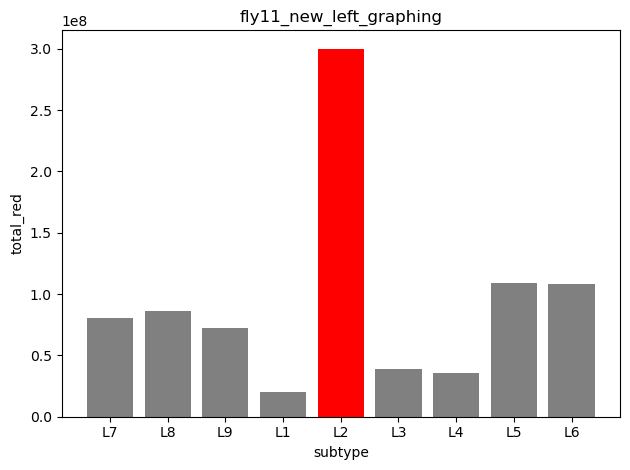

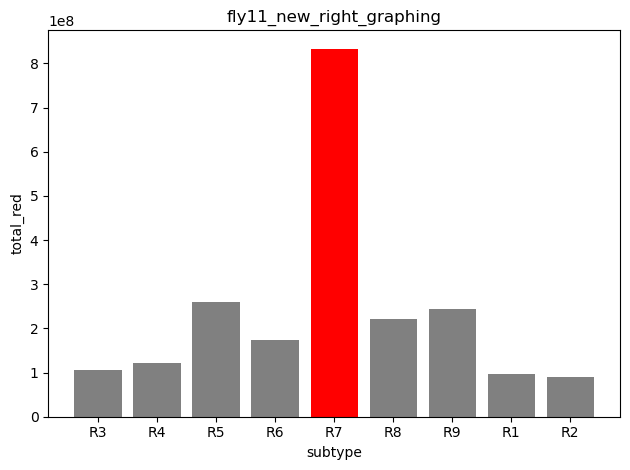

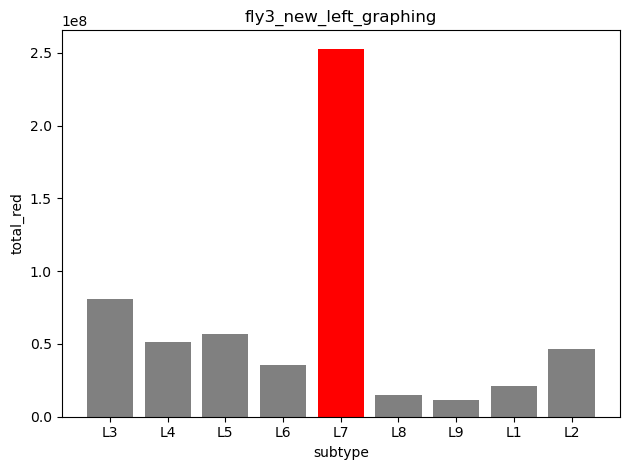

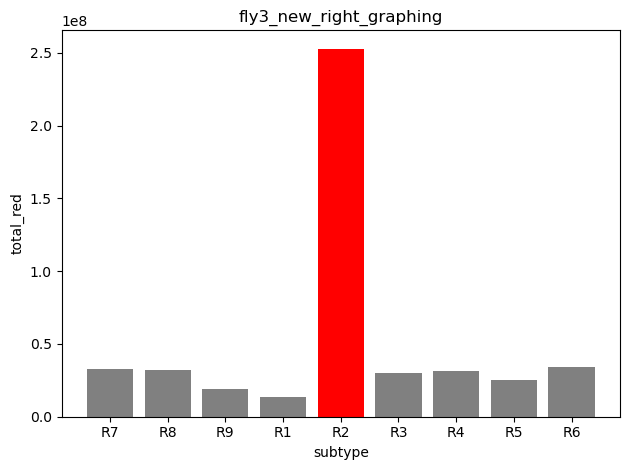

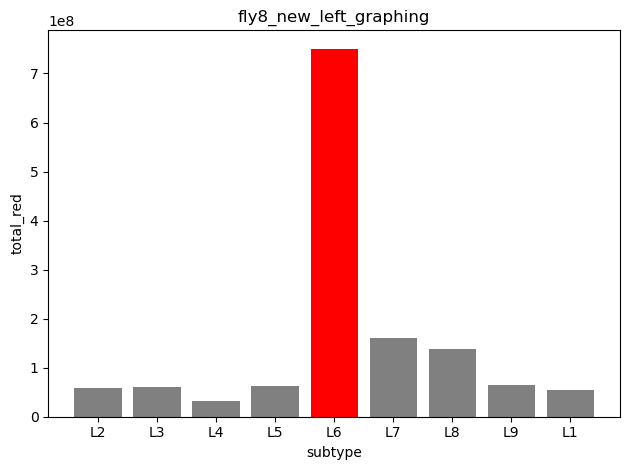

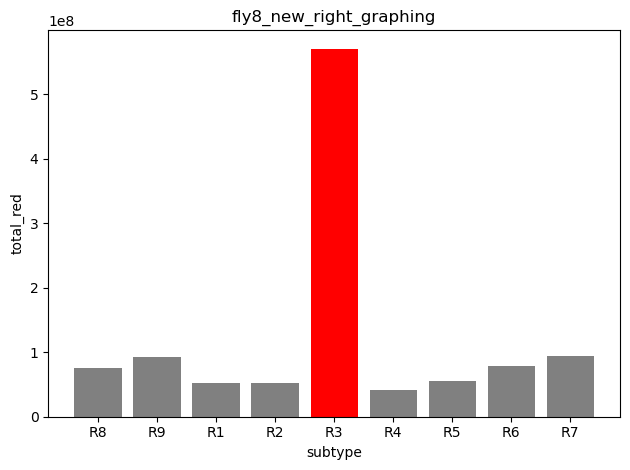

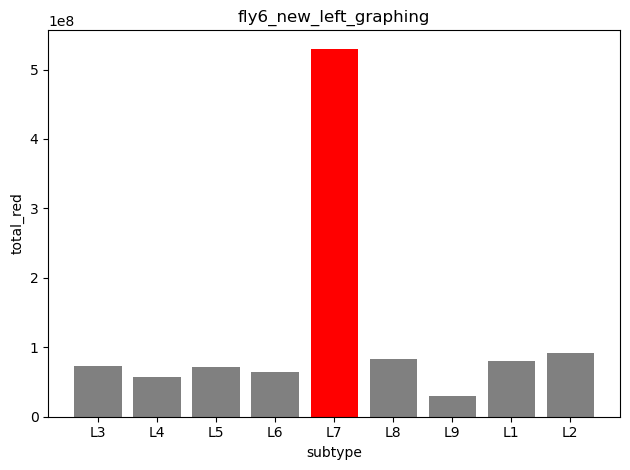

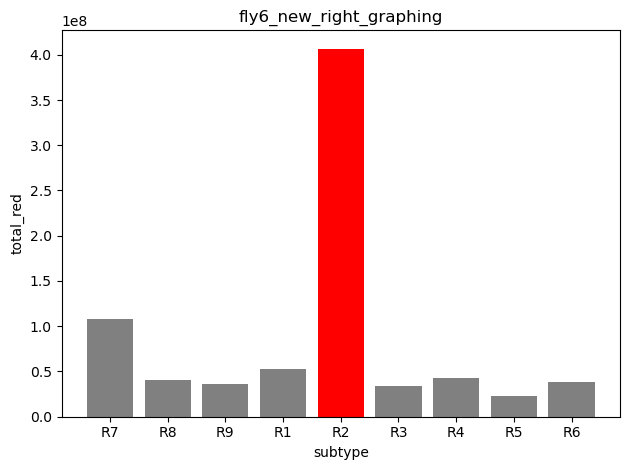

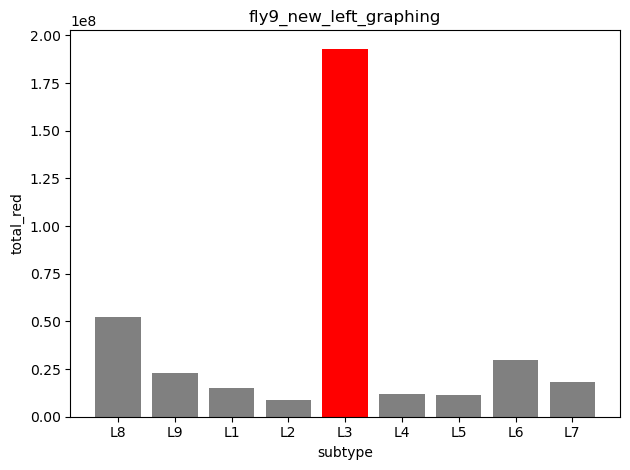

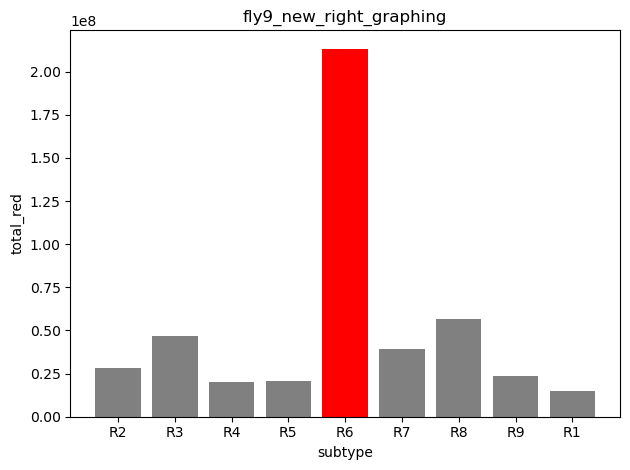

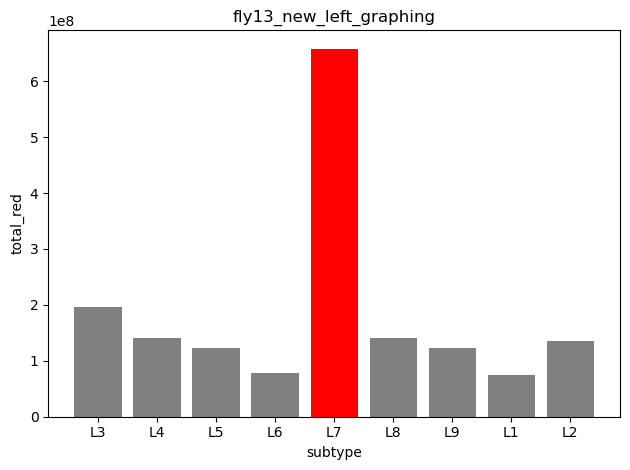

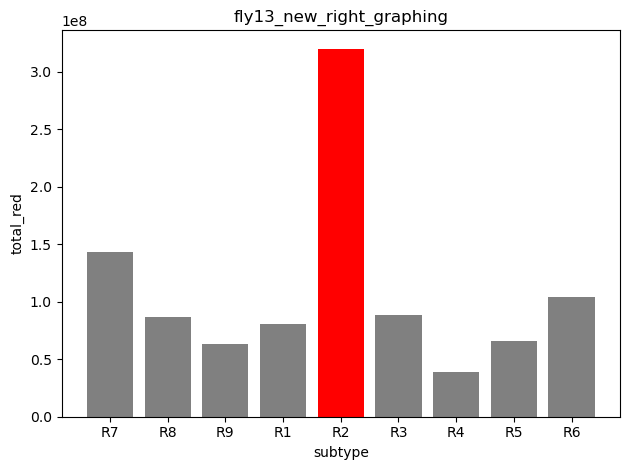

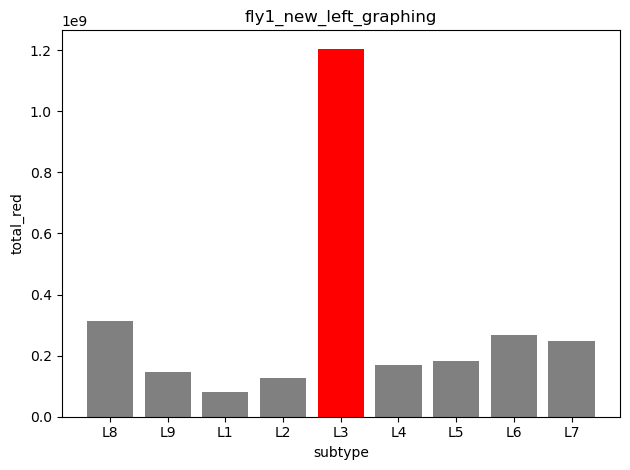

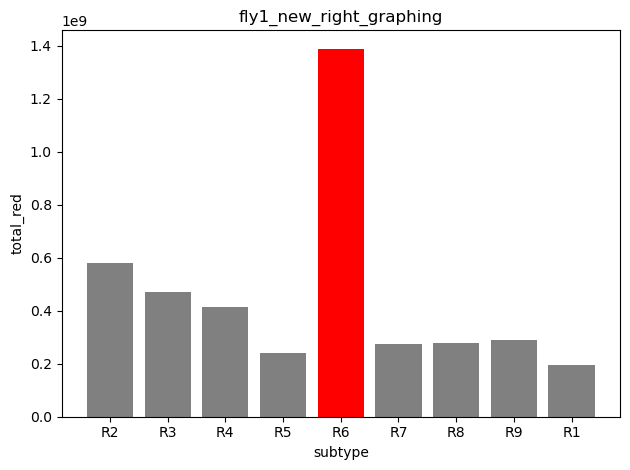

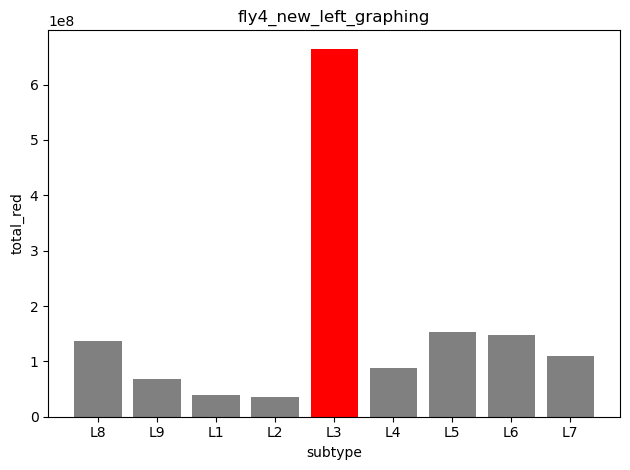

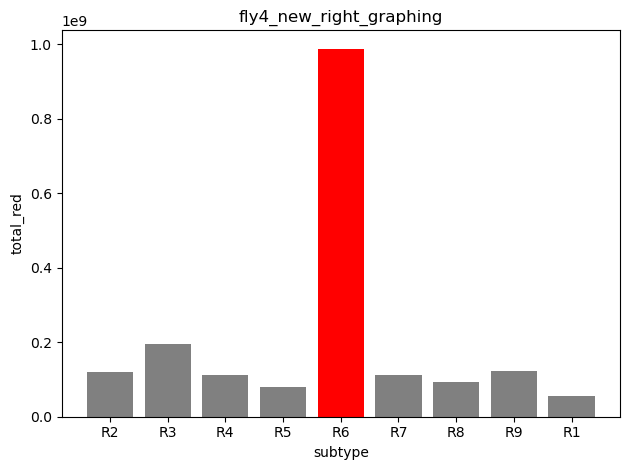

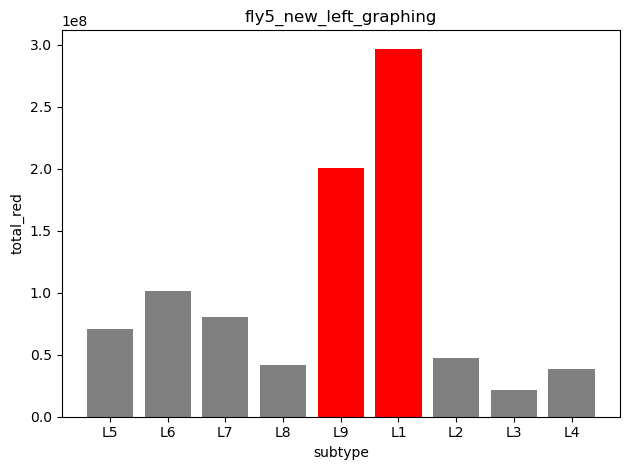

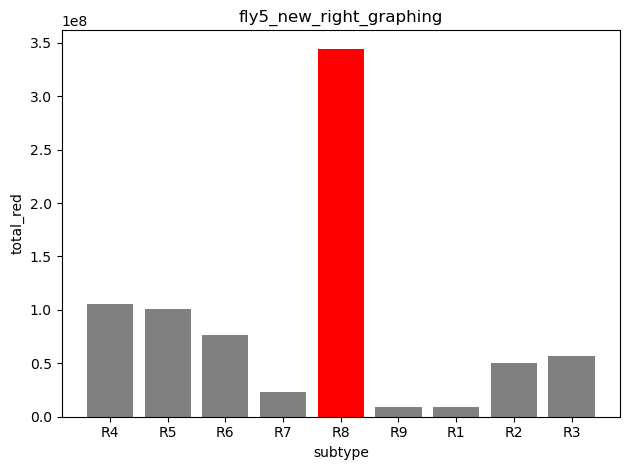

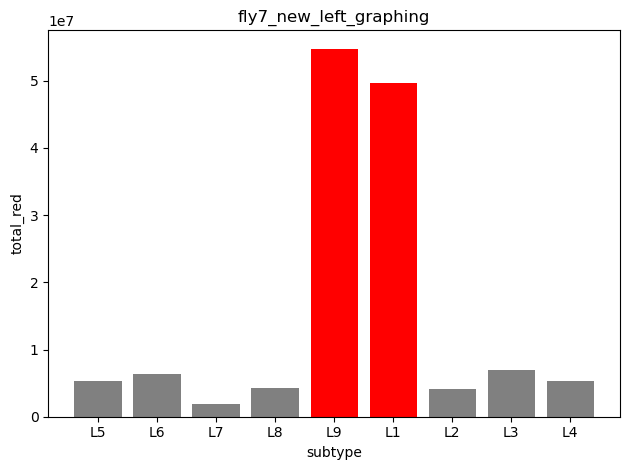

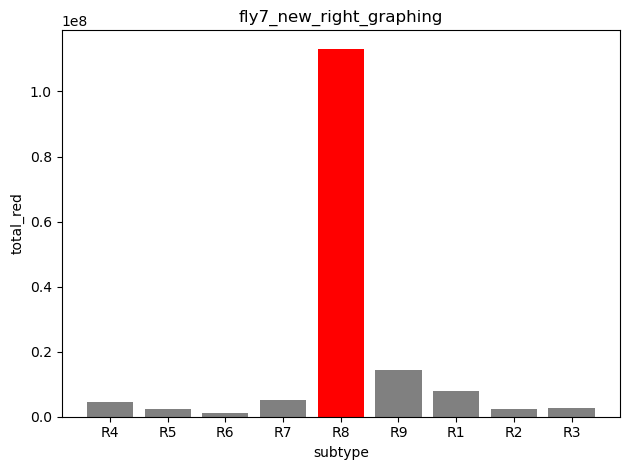

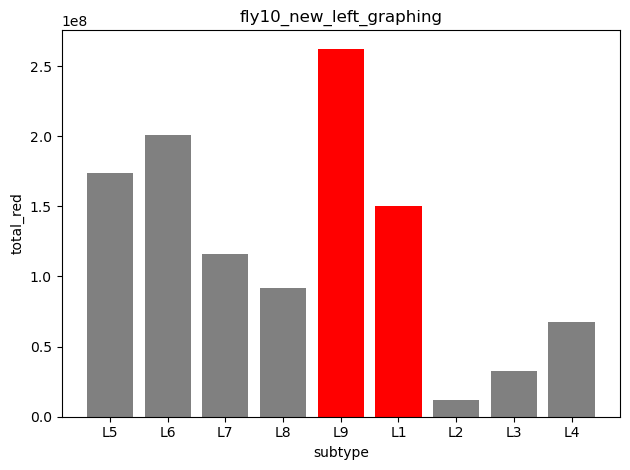

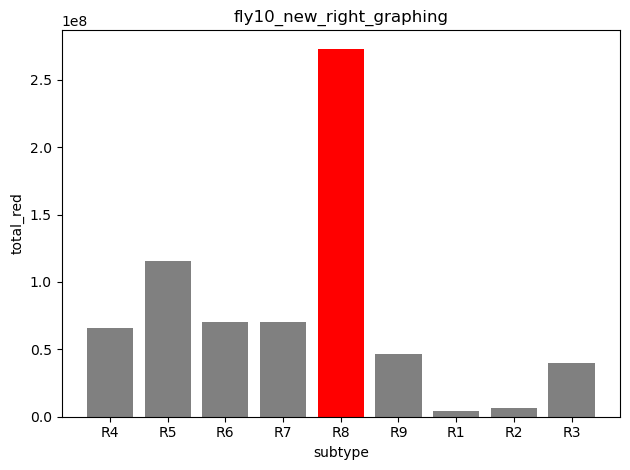

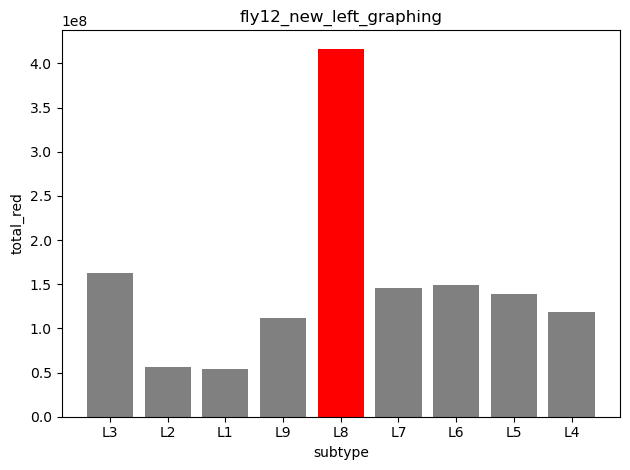

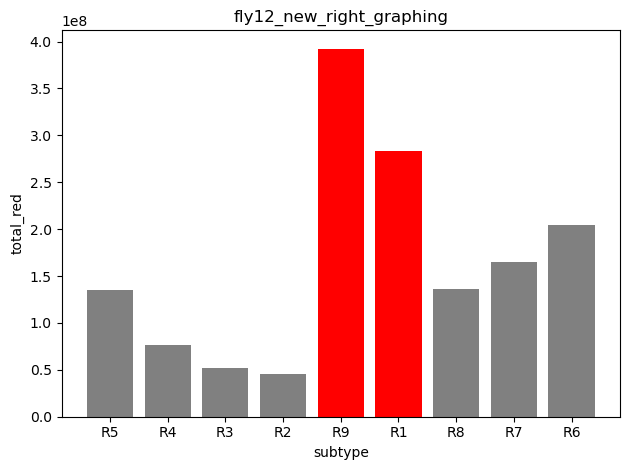

In [28]:
graphing_dfs = [
    name for name in globals()
    if re.match(r'fly\d+_new_(?:left|right)_graphing$', name)
]

# 2. Loop and plot, coloring all zero‐value subtypes in red
for df_name in graphing_dfs:
    df = globals()[df_name]
    if 'total_red' not in df.columns:
        continue

    x = df['subtype']
    y = df['total_red']

    # 3. Find the matching shuffle_order_for_graph table
    shuffle_name = re.sub(r'_graphing$', '_shuffle_order_for_graph', df_name)
    zeros = set()
    if shuffle_name in globals():
        shuffle_df = globals()[shuffle_name]
        # 4. Collect all subtypes where value == 0
        zeros = set(shuffle_df.loc[shuffle_df['value'] == 0, 'subtype'])

    # 5. Build colors: red for any subtype in zeros, gray otherwise
    colors = ['red' if s in zeros else 'gray' for s in x]

    # 6. Plot
    plt.figure()
    plt.bar(x, y, color=colors)
    plt.xlabel('subtype')
    plt.ylabel('total_red')
    plt.title(df_name)
    plt.tight_layout()
    plt.show()

In [29]:
graphing_dfs

['fly11_new_left_graphing',
 'fly11_new_right_graphing',
 'fly3_new_left_graphing',
 'fly3_new_right_graphing',
 'fly8_new_left_graphing',
 'fly8_new_right_graphing',
 'fly6_new_left_graphing',
 'fly6_new_right_graphing',
 'fly9_new_left_graphing',
 'fly9_new_right_graphing',
 'fly13_new_left_graphing',
 'fly13_new_right_graphing',
 'fly1_new_left_graphing',
 'fly1_new_right_graphing',
 'fly4_new_left_graphing',
 'fly4_new_right_graphing',
 'fly5_new_left_graphing',
 'fly5_new_right_graphing',
 'fly7_new_left_graphing',
 'fly7_new_right_graphing',
 'fly10_new_left_graphing',
 'fly10_new_right_graphing',
 'fly12_new_left_graphing',
 'fly12_new_right_graphing']